# Local and full spectral functions

For very large systems, exact diagonalization becomes impractical. Passing `mode="KPM"` to
`h.get_dos()` switches to a stochastic Chebyshev kernel polynomial expansion, which never builds
the full spectrum: it estimates the trace of a spectral function through a random-vector stochastic
trace, expanded in Chebyshev polynomials of the (rescaled) Hamiltonian. The same machinery gives
the **local** DOS at a single site by seeding the expansion with a delta vector at that site instead
of a random vector (`h.get_ldos(mode="KPM")`), letting the full and local spectral function be
compared directly on a large sparse system.

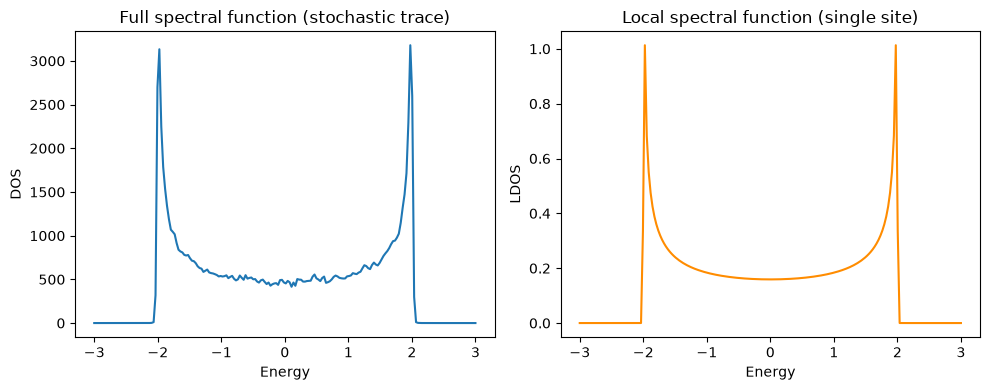

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.ldos import dos_site

g = geometry.chain()
g = g.get_supercell(3000) # a big supercell
g.dimensionality = 0
h = g.get_hamiltonian(is_sparse=True,has_spin=False)

energies = np.linspace(-3.0,3.0,200)
x,y_full = h.get_dos(mode="KPM",energies=energies,delta=1e-2,ntries=10)
x,y_local = dos_site(h,i=1500,mode="KPM",energies=energies,delta=1e-2)

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(x,y_full)
axs[0].set_xlabel("Energy") ; axs[0].set_ylabel("DOS")
axs[0].set_title("Full spectral function (stochastic trace)")
axs[1].plot(x,y_local,c="darkorange")
axs[1].set_xlabel("Energy") ; axs[1].set_ylabel("LDOS")
axs[1].set_title("Local spectral function (single site)")
plt.tight_layout()
plt.show()

Resolving the local spectral function site by site gives a map of the LDOS as a function of the
distance to the end of the chain and of the energy. Close to the end, the LDOS is modulated by the
standing waves that the edge creates, and the wavelength of the modulation changes with energy,
following the wavevector of the states of the chain at that energy.

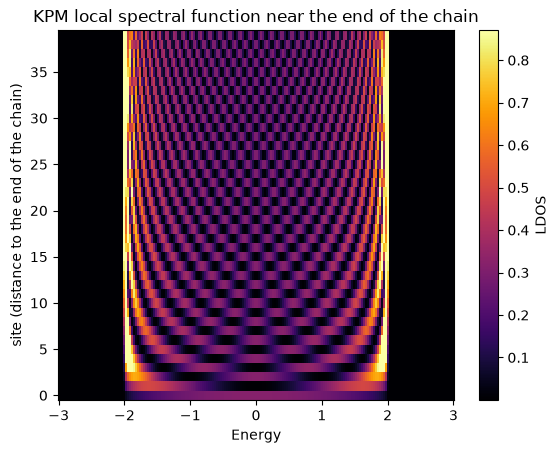

In [2]:
sites = np.arange(40) # the first 40 sites, starting at the end of the chain
ldos_map = np.array([dos_site(h,i=i,mode="KPM",energies=energies,delta=3e-2)[1] for i in sites])

plt.pcolormesh(energies,sites,ldos_map,cmap="inferno",shading="auto",vmax=np.percentile(ldos_map,98))
plt.colorbar(label="LDOS")
plt.xlabel("Energy") ; plt.ylabel("site (distance to the end of the chain)")
plt.title("KPM local spectral function near the end of the chain")
plt.show()